In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import os
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.makedirs('model', exist_ok=True)
os.makedirs('output', exist_ok=True)

Using device: cuda


In [2]:
DATA_XLSX = "/kaggle/input/sandhi-data/sandhi_data.xlsx"
SHEET_NAME = 0
df = pd.read_excel(DATA_XLSX, sheet_name=SHEET_NAME)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nData types:")
print(df.dtypes)
print(f"\nNull values:")
print(df.isnull().sum())

print("\n" + "="*80)
print("SAMPLE EXAMPLES:")
print("="*80)
for idx in range(min(5, len(df))):
    print(f"\nExample {idx+1}:")
    for col in df.columns:
        print(f"  {col}: {df.iloc[idx][col]}")

Dataset shape: (13930, 2)

Columns: ['Word', 'Split']

First few rows:
                                Word                                 Split
0                        प्रथमोऽङ्कः                          प्रथमः+अङ्कः
1                            शब्द इव                              शब्दः+इव
2                             इत इतः                               इतः+इतः
3                            कुतो नु                               कुतः+नु
4  खल्वेष समुत्थितो समुत्थितो ध्वनिः    खलु+एषः+समुत्थितः+समुत्थितः+ध्वनिः
5                             एष खलु                               एषः+खलु
6                     रामो हनुमांश्च                        रामः+हनुमान्+च
7                           भयं त्यज                             भयम्+त्यज
8                              ममापि                                मम+अपि
9    कथं कथं कथं सुग्रीव सुग्रीव इति  कथम्+कथम्+कथम्+सुग्रीवः+सुग्रीवः+इति

Data types:
Word     object
Split    object
dtype: object

Null values:
Word     0
Split    5
dtype: in

In [3]:
class SandhiPreprocessor:
    """
    Converts sandhied + split pairs into character sequences with B/I labels
    Following Hellwig (2015) formulation
    """
    def __init__(self):
        self.char2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2char = {0: '<PAD>', 1: '<UNK>'}
        self.label2idx = {'I': 0, 'B': 1}
        self.idx2label = {0: 'I', 1: 'B'}
        
    def build_vocab(self, texts):
        """Build character vocabulary from training data"""
        char_counts = Counter()
        for text in texts:
            if pd.notna(text):  # Skip NaN values
                char_counts.update(str(text))
        
        # Add characters to vocab (sorted for reproducibility)
        for char, count in sorted(char_counts.items()):
            if char not in self.char2idx and char not in [' ', '\t', '\n']:
                idx = len(self.char2idx)
                self.char2idx[char] = idx
                self.idx2char[idx] = char
        
        print(f"Vocabulary size: {len(self.char2idx)}")
        print(f"Sample characters: {list(self.char2idx.keys())[:20]}")
        return self
    
    def align_and_label(self, sandhied, split):
        """
        Create character-level labels for boundary detection
        
        Strategy:
        1. Extract individual words from split string (remove '+' and spaces)
        2. Try to align these words with sandhied string
        3. Mark boundaries between words
        
        Example:
          sandhied: "रामोऽस्ति"
          split: "रामः + अस्ति"
          words: ["रामः", "अस्ति"]
        
        Returns:
          chars: list of characters from sandhied
          labels: list of labels ('I' or 'B')
        """
        # Clean the split string - handle multiple formats
        split_clean = str(split).strip()
        
        # Split by '+' or other delimiters
        if '+' in split_clean:
            parts = [p.strip() for p in split_clean.split('+')]
        elif ' ' in split_clean:
            parts = [p.strip() for p in split_clean.split()]
        else:
            # No clear delimiter, treat as single word
            parts = [split_clean]
        
        # Remove empty parts
        parts = [p for p in parts if p]
        
        sandhied = str(sandhied).strip()
        chars = list(sandhied)
        labels = ['I'] * len(chars)
        
        # If only one part, no boundaries
        if len(parts) <= 1:
            return chars, labels
        
        # Method 1: Try exact substring matching
        # This works if split words appear in sandhied
        current_pos = 0
        for i, part in enumerate(parts):
            if i == 0:
                # First word - find where it ends
                # Mark boundary after it (before next word starts)
                current_pos = len(part)
                if current_pos < len(chars):
                    # Check if we should mark boundary here or slightly adjusted
                    # Sometimes sandhi changes last character
                    boundary_pos = min(current_pos, len(chars) - 1)
                    if boundary_pos + 1 < len(chars):
                        labels[boundary_pos + 1] = 'B'
            else:
                # Subsequent words
                # Find this word in remaining sandhied string
                remaining = sandhied[current_pos:]
                
                # Try to find the word (might be slightly modified by sandhi)
                found_pos = -1
                
                # Exact match
                if part in remaining:
                    found_pos = remaining.index(part)
                # Try first few characters
                elif len(part) >= 2 and part[:2] in remaining:
                    found_pos = remaining.index(part[:2])
                # Try first character
                elif len(part) >= 1 and part[0] in remaining:
                    found_pos = remaining.index(part[0])
                
                if found_pos >= 0:
                    boundary_idx = current_pos + found_pos
                    if 0 < boundary_idx < len(chars):
                        labels[boundary_idx] = 'B'
                    current_pos = boundary_idx + len(part)
        
        # Method 2: If above fails, use approximate positions
        # based on word lengths
        if labels.count('B') != len(parts) - 1:
            # Fallback: distribute boundaries evenly
            labels = ['I'] * len(chars)
            if len(parts) > 1:
                # Calculate approximate boundary positions
                words_concat = ''.join(parts)
                ratio = len(sandhied) / max(len(words_concat), 1)
                
                cumulative = 0
                for i, part in enumerate(parts[:-1]):  # All except last
                    cumulative += len(part)
                    boundary_idx = int(cumulative * ratio)
                    if 0 < boundary_idx < len(chars):
                        labels[boundary_idx] = 'B'
        
        return chars, labels
    
    def encode_sequence(self, chars):
        """Convert characters to indices"""
        return [self.char2idx.get(c, self.char2idx['<UNK>']) for c in chars]
    
    def encode_labels(self, labels):
        """Convert labels to indices"""
        return [self.label2idx[l] for l in labels]
    
    def decode_sequence(self, indices):
        """Convert indices back to characters"""
        return [self.idx2char.get(i, '<UNK>') for i in indices]
    
    def process_dataset(self, df, sandhied_col='sandhied', split_col='split'):
        """Process entire dataset"""
        processed = []
        errors = []
        
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
            try:
                sandhied = str(row[sandhied_col]).strip()
                split = str(row[split_col]).strip()
                
                # Skip invalid entries
                if pd.isna(sandhied) or pd.isna(split) or sandhied == 'nan' or split == 'nan':
                    continue
                
                if len(sandhied) == 0 or len(split) == 0:
                    continue
                
                chars, labels = self.align_and_label(sandhied, split)
                char_ids = self.encode_sequence(chars)
                label_ids = self.encode_labels(labels)
                
                processed.append({
                    'chars': chars,
                    'labels': labels,
                    'char_ids': char_ids,
                    'label_ids': label_ids,
                    'sandhied': sandhied,
                    'split': split,
                    'original_idx': idx
                })
            except Exception as e:
                errors.append((idx, str(e)))
                continue
        
        if errors:
            print(f"\n⚠️  {len(errors)} errors during processing")
            print("First few errors:")
            for idx, err in errors[:5]:
                print(f"  Row {idx}: {err}")
        
        print(f"\n Successfully processed {len(processed)} examples")
        return processed
    
    def save_meta(self, filepath):
        """Save metadata for inference"""
        meta = {
            'char2idx': self.char2idx,
            'idx2char': self.idx2char,
            'label2idx': self.label2idx,
            'idx2label': self.idx2label,
            'vocab_size': len(self.char2idx)
        }
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)
        print(f"Saved metadata to {filepath}")
    
    @classmethod
    def load_meta(cls, filepath):
        """Load metadata for inference"""
        with open(filepath, 'r', encoding='utf-8') as f:
            meta = json.load(f)
        
        preprocessor = cls()
        preprocessor.char2idx = meta['char2idx']
        preprocessor.idx2char = {int(k): v for k, v in meta['idx2char'].items()}
        preprocessor.label2idx = meta['label2idx']
        preprocessor.idx2label = {int(k): v for k, v in meta['idx2label'].items()}
        
        return preprocessor

In [4]:
SANDHIED_COL = df.columns[0] 
SPLIT_COL = df.columns[1]

print(f"\nUsing columns:")
print(f"  Sandhied: '{SANDHIED_COL}'")
print(f"  Split: '{SPLIT_COL}'")

preprocessor = SandhiPreprocessor()
print("\nBuilding vocabulary...")
preprocessor.build_vocab(df[SANDHIED_COL].tolist())
print("\nProcessing dataset...")
processed_data = preprocessor.process_dataset(df, sandhied_col=SANDHIED_COL, split_col=SPLIT_COL)

print("\n" + "="*80)
print("PROCESSED EXAMPLES:")
print("="*80)
for i in range(min(5, len(processed_data))):
    item = processed_data[i]
    print(f"\nExample {i+1}:")
    print(f"  Sandhied: {item['sandhied']}")
    print(f"  Split: {item['split']}")
    print(f"  Chars: {' '.join(item['chars'])}")
    print(f"  Labels: {' '.join(item['labels'])}")
    print(f"  Boundaries at positions: {[i for i, l in enumerate(item['labels']) if l == 'B']}")

preprocessor.save_meta('model/meta.json')


Using columns:
  Sandhied: 'Word'
  Split: 'Split'

Building vocabulary...
Vocabulary size: 82
Sample characters: ['<PAD>', '<UNK>', '"', "'", '(', ')', '+', ',', '-', '.', '1', '2', ':', ';', 'S', 's', 'ँ', 'ं', 'ः', 'अ']

Processing dataset...


Processing: 100%|██████████| 13930/13930 [00:00<00:00, 16129.71it/s]


 Successfully processed 13925 examples

PROCESSED EXAMPLES:

Example 1:
  Sandhied: प्रथमोऽङ्कः
  Split: प्रथमः+अङ्कः
  Chars: प ् र थ म ो ऽ ङ ् क ः
  Labels: I I I I I I I B I I I
  Boundaries at positions: [7]

Example 2:
  Sandhied: शब्द इव
  Split: शब्दः+इव
  Chars: श ब ् द   इ व
  Labels: I I I I I B I
  Boundaries at positions: [5]

Example 3:
  Sandhied: इत इतः
  Split: इतः+इतः
  Chars: इ त   इ त ः
  Labels: I I I B I I
  Boundaries at positions: [3]

Example 4:
  Sandhied: कुतो नु
  Split: कुतः+नु
  Chars: क ु त ो   न ु
  Labels: I I I I I B I
  Boundaries at positions: [5]

Example 5:
  Sandhied: खल्वेष समुत्थितो समुत्थितो ध्वनिः
  Split: खलु+एषः+समुत्थितः+समुत्थितः+ध्वनिः
  Chars: ख ल ् व े ष   स म ु त ् थ ि त ो   स म ु त ् थ ि त ो   ध ् व न ि ः
  Labels: I I I I B I I B I I I I I I I I I B I I I I I I I I I B I I I I I
  Boundaries at positions: [4, 7, 17, 27]
Saved metadata to model/meta.json


In [5]:
class SandhiDataset(Dataset):
    """PyTorch Dataset for character sequences"""
    def __init__(self, processed_data):
        self.data = processed_data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            'char_ids': torch.tensor(item['char_ids'], dtype=torch.long),
            'label_ids': torch.tensor(item['label_ids'], dtype=torch.long),
            'length': len(item['char_ids']),
            'sandhied': item['sandhied'],
            'split': item['split']
        }

def collate_fn(batch):
    """Collate function for variable-length sequences"""
    # Get max length in batch
    max_len = max(item['length'] for item in batch)
    
    # Pad sequences
    char_ids = []
    label_ids = []
    lengths = []
    
    for item in batch:
        length = item['length']
        # Pad chars with 0 (PAD token)
        padded_chars = torch.cat([
            item['char_ids'],
            torch.zeros(max_len - length, dtype=torch.long)
        ])
        # CRITICAL FIX: Pad labels with -100 (ignore_index)
        padded_labels = torch.cat([
            item['label_ids'],
            torch.full((max_len - length,), -100, dtype=torch.long)
        ])
        
        char_ids.append(padded_chars)
        label_ids.append(padded_labels)
        lengths.append(length)
    
    return {
        'char_ids': torch.stack(char_ids),
        'label_ids': torch.stack(label_ids),
        'lengths': torch.tensor(lengths)
    }

# Split data: 80% train, 10% val, 10% test
train_data, test_data = train_test_split(processed_data, test_size=0.1, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.1111, random_state=42)

print(f"\nData splits:")
print(f"  Training: {len(train_data)} examples")
print(f"  Validation: {len(val_data)} examples")
print(f"  Test: {len(test_data)} examples")

# Create datasets
train_dataset = SandhiDataset(train_data)
val_dataset = SandhiDataset(val_data)
test_dataset = SandhiDataset(test_data)

# Create dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\nDataLoader created with batch size: {BATCH_SIZE}")


Data splits:
  Training: 11139 examples
  Validation: 1393 examples
  Test: 1393 examples

DataLoader created with batch size: 32


In [6]:
class BiLSTMSequenceLabeler(nn.Module):
    """
    BiLSTM Character-Level Sequence Labeling
    Following Hellwig (2015)
    """
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, 
                 num_layers=2, dropout=0.3, num_labels=2):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        self.bilstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # Output layer: 2*hidden_dim (bidirectional) -> num_labels
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
    def forward(self, char_ids, lengths):
        """
        Args:
            char_ids: (batch_size, max_len)
            lengths: (batch_size,)
        Returns:
            logits: (batch_size, max_len, num_labels)
        """
        # Embedding
        embedded = self.embedding(char_ids)  # (B, L, E)
        
        # Pack padded sequence
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        # BiLSTM
        packed_output, _ = self.bilstm(packed)
        
        # Unpack
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        # Dropout
        lstm_out = self.dropout(lstm_out)
        
        # Classification
        logits = self.classifier(lstm_out)  # (B, L, num_labels)
        
        return logits

# Initialize model
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3

model = BiLSTMSequenceLabeler(
    vocab_size=len(preprocessor.char2idx),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    num_labels=2
).to(device)

print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model Architecture:
BiLSTMSequenceLabeler(
  (embedding): Embedding(82, 64, padding_idx=0)
  (bilstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)

Total parameters: 599,682
Trainable parameters: 599,682


In [7]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(dataloader, desc="Training"):
        char_ids = batch['char_ids'].to(device)
        label_ids = batch['label_ids'].to(device)
        lengths = batch['lengths']
        
        # Forward
        optimizer.zero_grad()
        logits = model(char_ids, lengths)
        
        # Flatten for loss computation
        logits_flat = logits.view(-1, logits.size(-1))
        labels_flat = label_ids.view(-1)
        
        # Compute loss (automatically ignores padding due to ignore_index=0)
        loss = criterion(logits_flat, labels_flat)
        
        # Backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        # Accuracy (on non-padded positions)
        mask = (char_ids != 0)
        predictions = logits.argmax(dim=-1)
        correct += ((predictions == label_ids) & mask).sum().item()
        total += mask.sum().item()
    
    return total_loss / len(dataloader), correct / total

def evaluate(model, dataloader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            char_ids = batch['char_ids'].to(device)
            label_ids = batch['label_ids'].to(device)
            lengths = batch['lengths']
            
            logits = model(char_ids, lengths)
            
            logits_flat = logits.view(-1, logits.size(-1))
            labels_flat = label_ids.view(-1)
            loss = criterion(logits_flat, labels_flat)
            
            total_loss += loss.item()
            
            mask = (char_ids != 0)
            predictions = logits.argmax(dim=-1)
            correct += ((predictions == label_ids) & mask).sum().item()
            total += mask.sum().item()
            
            # Store for metrics (only non-padded positions)
            for i in range(len(lengths)):
                length = lengths[i]
                all_preds.extend(predictions[i, :length].cpu().tolist())
                all_labels.extend(label_ids[i, :length].cpu().tolist())
    
    return total_loss / len(dataloader), correct / total, all_preds, all_labels

In [8]:
total_i = sum(item['labels'].count('I') for item in train_data)
total_b = sum(item['labels'].count('B') for item in train_data)
total = total_i + total_b

weight_i = total / (2 * total_i)
weight_b = total / (2 * total_b)

print(f"\nClass Distribution:")
print(f"  'I' labels: {total_i} ({total_i/total*100:.1f}%)")
print(f"  'B' labels: {total_b} ({total_b/total*100:.1f}%)")
print(f"  Class Weights: I={weight_i:.4f}, B={weight_b:.4f}")

# Training configuration
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3

# CRITICAL FIX: Use ignore_index=-100 (matches padding)
class_weights = torch.tensor([weight_i, weight_b], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

# Re-initialize model to clear bad weights
model = BiLSTMSequenceLabeler(
    vocab_size=len(preprocessor.char2idx),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    num_labels=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5)

# Training loop
best_val_f1 = 0
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'val_boundary_f1': []
}

print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*80}")
    
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    
    precision, recall, f1, support = precision_recall_fscore_support(
        val_labels, val_preds, labels=[0, 1], average=None, zero_division=0
    )
    boundary_f1 = f1[1]
    
    scheduler.step(boundary_f1)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_boundary_f1'].append(boundary_f1)
    
    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Boundary F1: {boundary_f1:.4f}")
    print(f"  Label 'I': P={precision[0]:.4f}, R={recall[0]:.4f}, F1={f1[0]:.4f}")
    print(f"  Label 'B': P={precision[1]:.4f}, R={recall[1]:.4f}, F1={f1[1]:.4f}")
    
    if boundary_f1 > best_val_f1:
        best_val_f1 = boundary_f1
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_boundary_f1': boundary_f1,
            'config': {
                'vocab_size': len(preprocessor.char2idx),
                'embedding_dim': EMBEDDING_DIM,
                'hidden_dim': HIDDEN_DIM,
                'num_layers': NUM_LAYERS,
                'dropout': DROPOUT
            }
        }
        torch.save(checkpoint, f'model/best-epoch={epoch+1}.pt')
        print(f"Saved best model (F1: {boundary_f1:.4f})")

print(f"\n{'='*80}")
print(f"Best boundary F1: {best_val_f1:.4f}")


Class Distribution:
  'I' labels: 125987 (89.0%)
  'B' labels: 15595 (11.0%)
  Class Weights: I=0.5619, B=4.5393

STARTING TRAINING

Epoch 1/20


Evaluating: 100%|██████████| 44/44 [00:00<00:00, 169.80it/s]



Results:
  Train Loss: 0.4347 | Train Acc: 0.7989
  Val Loss:   0.3452 | Val Acc:   0.8364
  Boundary F1: 0.5385
  Label 'I': P=0.9768, R=0.8354, F1=0.9006
  Label 'B': P=0.3953, R=0.8441, F1=0.5385
Saved best model (F1: 0.5385)

Epoch 2/20


Evaluating: 100%|██████████| 44/44 [00:00<00:00, 173.57it/s]



Results:
  Train Loss: 0.3275 | Train Acc: 0.8550
  Val Loss:   0.2884 | Val Acc:   0.8870
  Boundary F1: 0.6326
  Label 'I': P=0.9804, R=0.8904, F1=0.9332
  Label 'B': P=0.5001, R=0.8603, F1=0.6326
Saved best model (F1: 0.6326)

Epoch 3/20


...


Results:
  Train Loss: 0.0534 | Train Acc: 0.9758
  Val Loss:   0.4239 | Val Acc:   0.9380
  Boundary F1: 0.7559
  Label 'I': P=0.9801, R=0.9493, F1=0.9645
  Label 'B': P=0.6811, R=0.8492, F1=0.7559

Epoch 19/20


Evaluating: 100%|██████████| 44/44 [00:00<00:00, 175.70it/s]



Results:
  Train Loss: 0.0509 | Train Acc: 0.9779
  Val Loss:   0.4241 | Val Acc:   0.9407
  Boundary F1: 0.7645
  Label 'I': P=0.9805, R=0.9520, F1=0.9661
  Label 'B': P=0.6935, R=0.8517, F1=0.7645

Epoch 20/20


Evaluating: 100%|██████████| 44/44 [00:00<00:00, 177.05it/s]


Results:
  Train Loss: 0.0354 | Train Acc: 0.9839
  Val Loss:   0.5015 | Val Acc:   0.9464
  Boundary F1: 0.7790
  Label 'I': P=0.9787, R=0.9604, F1=0.9695
  Label 'B': P=0.7293, R=0.8360, F1=0.7790
Saved best model (F1: 0.7790)

Best boundary F1: 0.7790


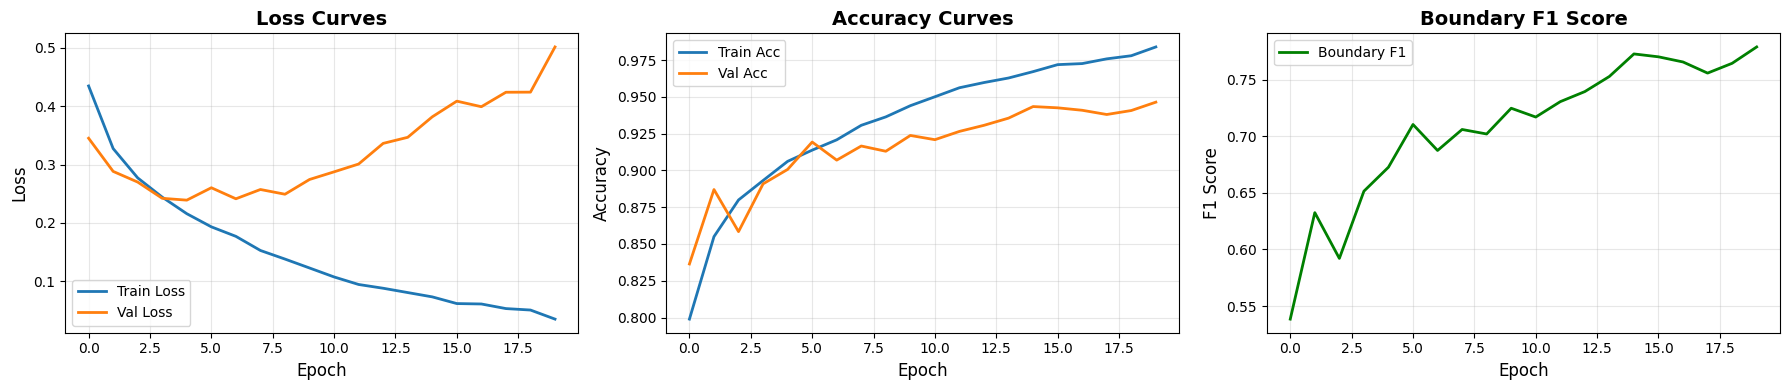

Training curves saved to output/training_curves.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Boundary F1
axes[2].plot(history['val_boundary_f1'], label='Boundary F1', linewidth=2, color='green')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('F1 Score', fontsize=12)
axes[2].set_title('Boundary F1 Score', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to output/training_curves.png")

Loading best checkpoint: model/best-epoch=6.pt
 Loaded model from epoch 6
  Val Accuracy: 0.9193
  Val Boundary F1: 0.7105

EVALUATING ON TEST SET


Evaluating: 100%|██████████| 44/44 [00:00<00:00, 179.19it/s]



Test Results:
  Test Loss: 0.2759
  Test Accuracy: 0.9234

BOUNDARY DETECTION METRICS
Label 'I' (Inside):   Precision=0.9804, Recall=0.9322, F1=0.9557, Support=14953
Label 'B' (Boundary): Precision=0.6194, Recall=0.8554, F1=0.7185, Support=1929

********************************************************************************
PRIMARY METRIC → Boundary F1 Score: 0.7185
********************************************************************************

Confusion Matrix:
              Predicted I  Predicted B
Actual I           13939        1014
Actual B             279        1650


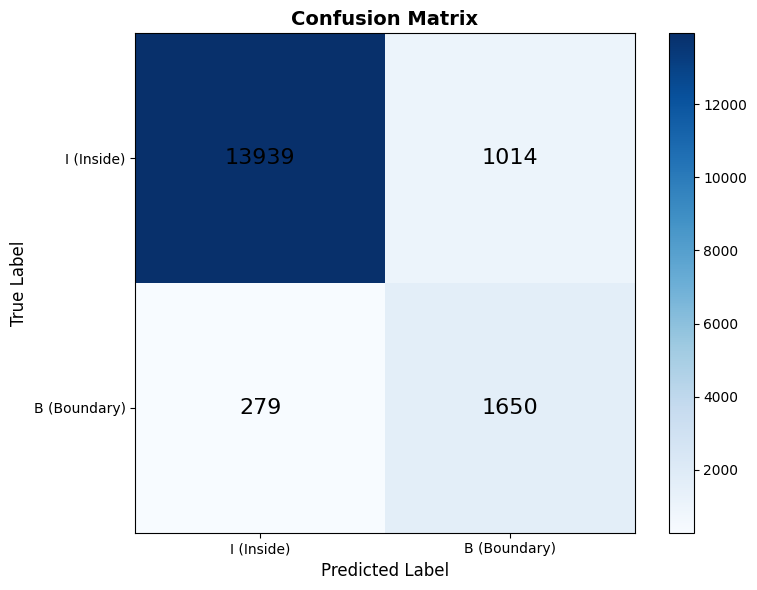


 Confusion matrix saved to output/confusion_matrix.png

SAMPLE PREDICTIONS


BiLSTMSequenceLabeler(
  (embedding): Embedding(82, 64, padding_idx=0)
  (bilstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)

In [10]:
# Find the best checkpoint
import glob
checkpoints = glob.glob('model/best-epoch=*.pt')
if checkpoints:
    best_checkpoint = sorted(checkpoints)[-1]
    print(f"Loading best checkpoint: {best_checkpoint}")
    
    # FIXED: Add weights_only=False for PyTorch 2.6+
    checkpoint = torch.load(best_checkpoint, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f" Loaded model from epoch {checkpoint['epoch']}")
    print(f"  Val Accuracy: {checkpoint['val_acc']:.4f}")
    print(f"  Val Boundary F1: {checkpoint['val_boundary_f1']:.4f}")
else:
    print("No checkpoint found, using current model")

# Evaluate on test set
print("\n" + "="*80)
print("EVALUATING ON TEST SET")
print("="*80)

test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f"\nTest Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")

# Compute detailed metrics for boundary detection
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, labels=[0, 1], average=None, zero_division=0
)

print(f"\n" + "="*80)
print("BOUNDARY DETECTION METRICS")
print("="*80)
print(f"Label 'I' (Inside):   Precision={precision[0]:.4f}, Recall={recall[0]:.4f}, F1={f1[0]:.4f}, Support={support[0]}")
print(f"Label 'B' (Boundary): Precision={precision[1]:.4f}, Recall={recall[1]:.4f}, F1={f1[1]:.4f}, Support={support[1]}")
print(f"\n{'*'*80}")
print(f"PRIMARY METRIC → Boundary F1 Score: {f1[1]:.4f}")
print(f"{'*'*80}")

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds, labels=[0, 1])
print(f"\nConfusion Matrix:")
print(f"              Predicted I  Predicted B")
print(f"Actual I      {cm[0,0]:10d}  {cm[0,1]:10d}")
print(f"Actual B      {cm[1,0]:10d}  {cm[1,1]:10d}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['I (Inside)', 'B (Boundary)'])
ax.set_yticklabels(['I (Inside)', 'B (Boundary)'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=16)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('output/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Confusion matrix saved to output/confusion_matrix.png")

# Show some example predictions
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)

model.eval()

In [11]:
metrics = {
    "best_validation": {
        "boundary_f1": float(best_val_f1)
    },
    "test_metrics": {
        "loss": float(test_loss),
        "accuracy": float(test_acc),
        "precision": {
            "I": float(precision[0]),
            "B": float(precision[1])
        },
        "recall": {
            "I": float(recall[0]),
            "B": float(recall[1])
        },
        "f1": {
            "I": float(f1[0]),
            "B": float(f1[1])  
        },
        "support": {
            "I": int(support[0]),
            "B": int(support[1])
        }
    },
    "confusion_matrix": {
        "labels": ["I", "B"],
        "matrix": cm.tolist()
    },
    "model_config": {
        "embedding_dim": EMBEDDING_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE
    },
    "notes": {
        "task": "Sanskrit Sandhi Boundary Detection",
        "model": "BiLSTM Character-Level Sequence Labeling",
        "paper_reference": "Hellwig (2015)",
        "primary_metric": "Boundary F1"
    }
}

# Save metrics.json
with open("metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("metrics.json saved")

metrics.json saved


In [12]:
import zipfile

ZIP_NAME = "RNN_sandhi_results.zip"

with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write("metrics.json")
    
    # Add output directory
    for foldername, subfolders, filenames in os.walk("output"):
        for filename in filenames:
            filepath = os.path.join(foldername, filename)
            zipf.write(filepath)
    
    # Add model directory
    for foldername, subfolders, filenames in os.walk("model"):
        for filename in filenames:
            filepath = os.path.join(foldername, filename)
            zipf.write(filepath)

print(f"All results zipped into {ZIP_NAME}")

from IPython.display import FileLink
FileLink("RNN_sandhi_results.zip")

All results zipped into RNN_sandhi_results.zip


/kaggle/working/RNN_sandhi_results.zip